# Cyber Classification Model - Experiments

This notebook regroups different experiments to build a classifier that determines whether an article from GDELT describes a cyberattack. This is purely informational to show a few experiments that were conducted in building models.

In [1]:
from google.colab import auth
auth.authenticate_user()

In [ ]:
%%bash
pip -q install transformers
pip install sentence-transformers
pip install datasets
pip install --upgrade openai

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pylab
from sklearn.model_selection import train_test_split
import numpy as np
import sklearn.metrics as metrics
import nltk
from nltk.corpus import stopwords
nltk.download('stopwords')

import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.linear_model import LogisticRegression

import transformers
from sentence_transformers import SentenceTransformer
from transformers import AutoModelForSequenceClassification, AutoTokenizer, Trainer, TrainingArguments
from datasets import Dataset

import os

from google.cloud import storage
import pickle
from openai import OpenAI

sns.set(style='darkgrid')

def figsize(width=10,length=10):
  pylab.rcParams['figure.figsize'] = width,length

In [ ]:
# Define the bucket and file path
bucket_name = os.environ.get("BUCKET_NAME")
file_path = 'cyber/models/linear-classifier/training_labeled_sample.csv'

# Create a client and get the blob
client = storage.Client()
bucket = client.bucket(bucket_name)
blob = bucket.blob(file_path)

# Open the blob as a file-like object and read it directly into pandas
with blob.open("r") as f:
    df = pd.read_csv(f)

In [5]:
df = df.dropna()

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(df.drop(columns=['is_attack']),df['is_attack'],test_size=0.33,random_state=42)
train = X_train.copy(deep=True)
train['is_attack'] = y_train

test = X_test.copy(deep=True)
test['is_attack'] = y_test

## Keywords

First, we see if keywords contained in an article are enough to predict if the article describes a cyberattack or not.

### Linear Classifier

In [ ]:
stopwords_list = stopwords.words('english')

In [ ]:
words = (" ".join(list(X_train['preprocessed_url']))).split(sep=' ')

top_words = list(pd.Series(words).value_counts().head(2000).index)

top_words = list(set(top_words) - set(stopwords_list))
top_words = [x for x in top_words if not x.isdigit()]

In [ ]:
for word in top_words:
  X_train[word] = X_train['preprocessed_url'].apply(lambda x: word in x.split()).astype(float)
  X_test[word] = X_test['preprocessed_url'].apply(lambda x: word in x.split()).astype(float)

In [ ]:
class LinearClassifier(nn.Module):

  def __init__(self,hidden_size):
    super(LinearClassifier, self).__init__()

    self.hidden_size = hidden_size
    self.linear = nn.Linear(hidden_size,1)

  def forward(self,inputs):
    return torch.sigmoid(self.linear(inputs))

In [ ]:
Lc = LinearClassifier(len(top_words))

In [ ]:
Lc.train()

LinearClassifier(
  (linear): Linear(in_features=1788, out_features=1, bias=True)
)

In [ ]:
criterion = nn.BCELoss()
optimizer = optim.SGD(Lc.parameters(), lr=1)
#optimizer = optim.Adam(Lc.parameters())

In [ ]:
n_epochs = 5000
losses = []
for epoch in range(n_epochs):  # loop over the dataset multiple times

  # zero the parameter gradients
  optimizer.zero_grad()

  # forward + backward + optimize
  outputs = Lc(torch.tensor(X_train[top_words].values).float())
  loss = criterion(outputs, torch.tensor(y_train.values.reshape(-1,1)).float())
  loss.backward()
  optimizer.step()

  # print statistics
  losses.append(loss.item())

print('Finished Training')

Finished Training


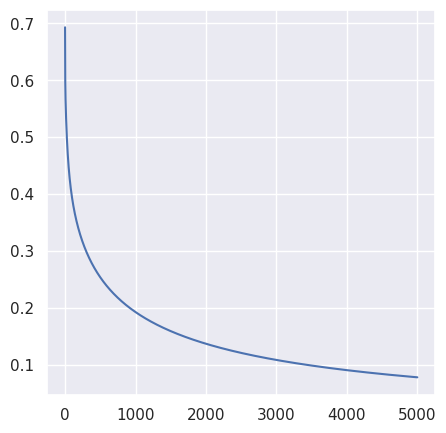

In [ ]:
figsize(5,5)
plt.plot(losses)

In [ ]:
Lc.eval()

LinearClassifier(
  (linear): Linear(in_features=1788, out_features=1, bias=True)
)

In [ ]:
X_test['linear_pred'] = Lc(torch.tensor(X_test[top_words].values).float()).detach().numpy()

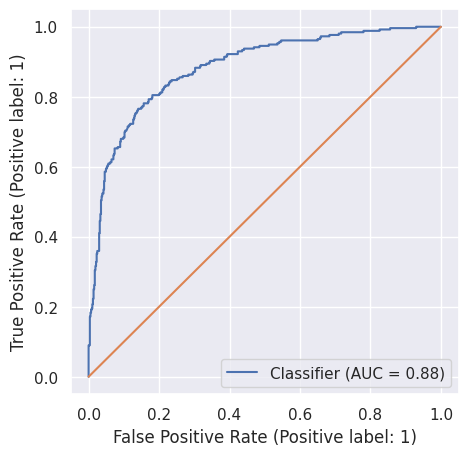

In [ ]:
metrics.RocCurveDisplay.from_predictions(y_test,X_test['linear_pred'])
plt.plot([0,1],[0,1])
plt.show()

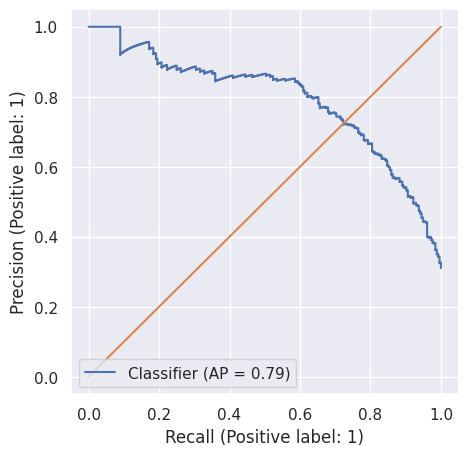

In [ ]:
metrics.PrecisionRecallDisplay.from_predictions(y_test,X_test['linear_pred'])
plt.plot([0,1],[0,1])
plt.show()

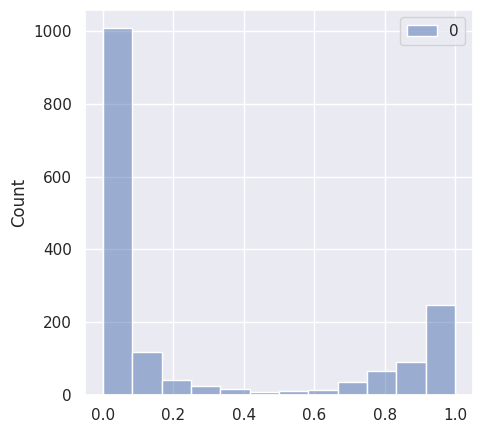

In [ ]:
sns.histplot(Lc(torch.tensor(X_train[top_words].values).float()).detach().numpy())
plt.show()

In [ ]:
threshold = np.mean(Lc(torch.tensor(X_train[top_words].values).float()).detach().numpy().reshape(1,-1)[0])

In [ ]:
print(threshold)

0.2790123


In [ ]:
print(metrics.classification_report(y_test,X_test['linear_pred'] > threshold))

              precision    recall  f1-score   support

         0.0       0.88      0.87      0.88       569
         1.0       0.72      0.75      0.73       256

    accuracy                           0.83       825
   macro avg       0.80      0.81      0.81       825
weighted avg       0.83      0.83      0.83       825



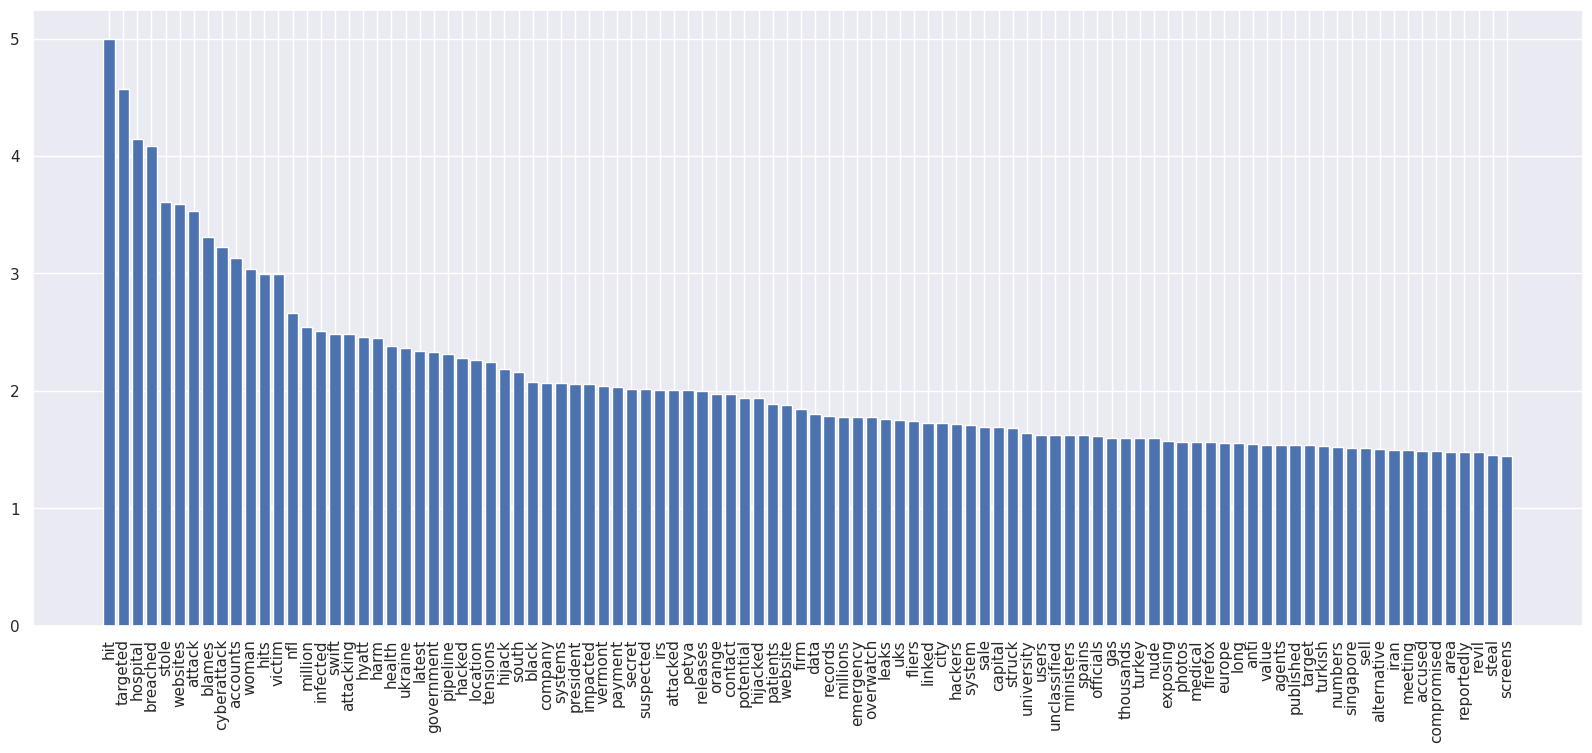

In [ ]:
figsize(20,8)
feature_importance = pd.DataFrame([top_words,Lc.linear.weight[0].detach().numpy()],index=['word','importance']).T.sort_values('importance',ascending=False)
plt.bar(feature_importance['word'][:100], feature_importance['importance'][:100])
plt.xticks(rotation=90)
plt.show()

### Logistic Regression

In [ ]:
lr = LogisticRegression()
lr.fit(X_train[top_words],y_train)

LogisticRegression()

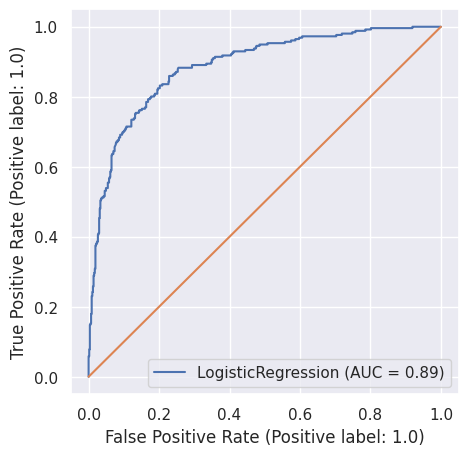

In [ ]:
figsize(5,5)
metrics.RocCurveDisplay.from_estimator(lr,X_test[top_words],y_test)
plt.plot([0,1],[0,1])

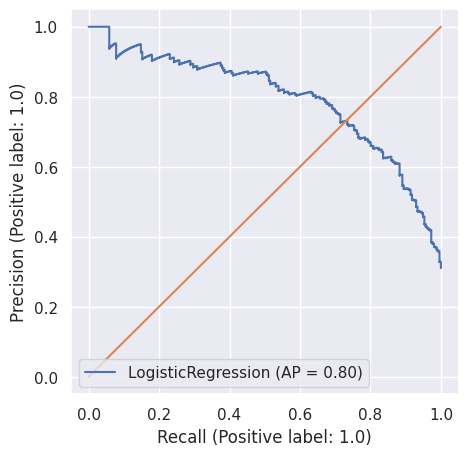

In [ ]:
metrics.PrecisionRecallDisplay.from_estimator(lr,X_test[top_words],y_test)
plt.plot([0,1],[0,1])
plt.show()

In [ ]:
threshold = np.mean(lr.predict_proba(X_train[top_words])[:,1])

In [ ]:
print(metrics.classification_report(y_test,lr.predict_proba(X_test[top_words])[:,1] > threshold))

              precision    recall  f1-score   support

         0.0       0.89      0.85      0.87       569
         1.0       0.69      0.77      0.73       256

    accuracy                           0.82       825
   macro avg       0.79      0.81      0.80       825
weighted avg       0.83      0.82      0.82       825



## Embeddings models

Second, instead of using keywords, we use the semantic meaning through embeddings.

### BERT

In [ ]:
tokenizer = transformers.AutoTokenizer.from_pretrained('distilbert-base-cased')
#tokenizer = transformers.DistilBertTokenizer.from_pretrained("distilbert-base-uncased-finetuned-sst-2-english")

def vectorize_batch(batch, tokenizer):
  #batch here is a slice of the dataframe
  url_batch = list(batch.preprocessed_url)
  outcome_values = list(batch.is_attack)
      # Encode the transcript
  url_encode = tokenizer.batch_encode_plus(url_batch,
    truncation = True,
    padding = 'longest',
    return_attention_mask = True,
    return_tensors = 'pt' )
  url_ids = url_encode['input_ids'].cuda()
  url_attn_mask = url_encode['attention_mask'].cuda()
  outcome_values = torch.LongTensor(outcome_values).cuda()
  return url_ids, url_attn_mask, outcome_values

In [ ]:
lm_pretrained = transformers.AutoModel.from_pretrained('distilbert-base-cased').cuda()
#lm_pretrained = transformers.AutoModel.from_pretrained('distilbert-base-uncased-finetuned-sst-2-english').cuda()

In [ ]:
batch_size = 10
batch = train.iloc[:batch_size]
input_ids, input_attn_mask, outcome_values = vectorize_batch(batch, tokenizer)
outputs = lm_pretrained(input_ids, input_attn_mask)

features = outputs.last_hidden_state[:,0,:].to('cpu').detach().numpy()
target = outcome_values.tolist()

for i in range(batch_size,len(train),batch_size):
  batch = train.iloc[i:i+batch_size]
  input_ids, input_attn_mask, outcome_values = vectorize_batch(batch, tokenizer)
  outputs = lm_pretrained(input_ids, input_attn_mask)
  hidden_state = outputs.last_hidden_state[:,0,:].to('cpu').detach().numpy()
  features = np.concatenate((features,hidden_state),axis=0)
  target+= outcome_values.tolist()

In [ ]:
batch_size = 10
batch = test.iloc[:batch_size]
input_ids, input_attn_mask, outcome_values = vectorize_batch(batch, tokenizer)
outputs = lm_pretrained(input_ids, input_attn_mask)
features_test = outputs.last_hidden_state[:,0,:].to('cpu').detach().numpy()

target_test = outcome_values.tolist()
for i in range(batch_size,len(test),batch_size):
  batch = test.iloc[i:i+batch_size]
  input_ids, input_attn_mask, outcome_values = vectorize_batch(batch,tokenizer)
  outputs = lm_pretrained( input_ids, input_attn_mask)
  hidden_state = outputs.last_hidden_state[:,0,:].to('cpu').detach().numpy()
  features_test = np.concatenate((features_test,hidden_state),axis=0)
  target_test+= outcome_values.tolist()

In [ ]:
_,p = features.shape
Lc_bert = LinearClassifier(p)

criterion = nn.BCELoss()
#optimizer = optim.SGD(Lc_bert.parameters(), lr=0.01)
optimizer = optim.Adam(Lc_bert.parameters(),lr=0.01)

In [ ]:
n_epochs = 10000
losses = []
for epoch in range(n_epochs):  # loop over the dataset multiple times

  # zero the parameter gradients
  optimizer.zero_grad()

  # forward + backward + optimize
  outputs = Lc_bert(torch.tensor(features).float())
  loss = criterion(outputs, torch.tensor(np.array(target).reshape(-1,1)).float())
  loss.backward()
  optimizer.step()

  # print statistics
  losses.append(loss.item())

print('Finished Training')

Finished Training


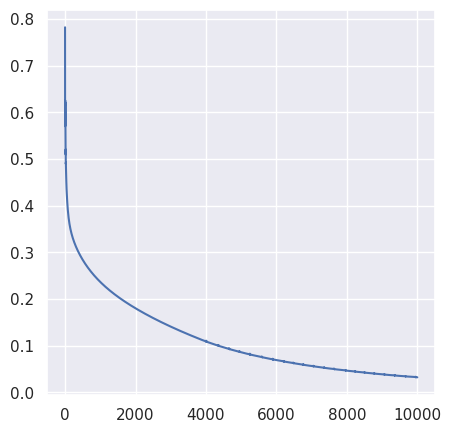

In [ ]:
figsize(5,5)
plt.plot(losses)

In [ ]:
X_test['bert_pred'] = Lc_bert(torch.tensor(features_test).float()).detach().numpy()

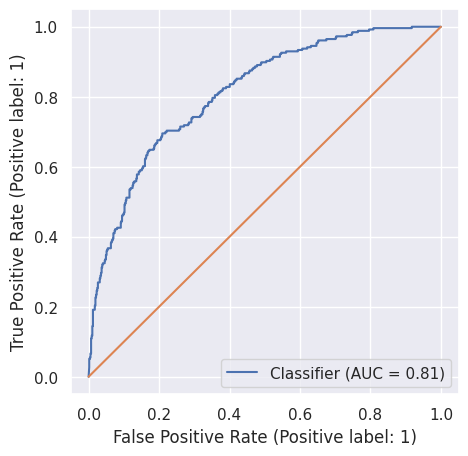

In [ ]:
metrics.RocCurveDisplay.from_predictions(target_test,X_test['bert_pred'])
plt.plot([0,1],[0,1])
plt.show()

### SFR Embedding

In [ ]:
model = SentenceTransformer('Salesforce/SFR-Embedding-2_R')

In [ ]:
X_train = model.encode(list(train['preprocessed_url']))

In [ ]:
X_test = model.encode(list(test['preprocessed_url']))

In [ ]:
Lr = LogisticRegression()

Lr.fit(X_train,train['is_attack'])

LogisticRegression()

In [ ]:
test['SFR_proba'] = Lr.predict_proba(X_test)[:,1]
test['SFR_pred'] = Lr.predict(X_test)

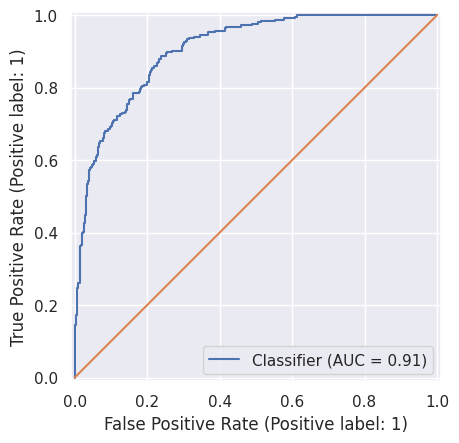

In [ ]:
metrics.RocCurveDisplay.from_predictions(test['is_attack'],test['SFR_proba'])
plt.plot([0,1],[0,1])
plt.show()

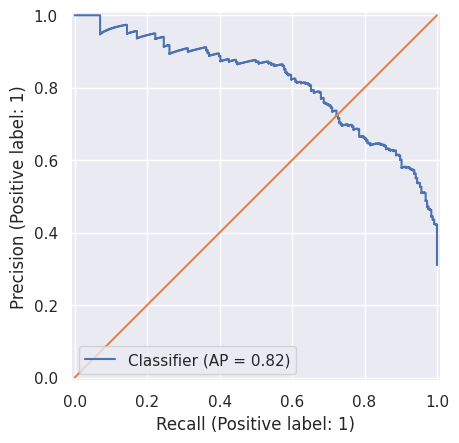

In [ ]:
metrics.PrecisionRecallDisplay.from_predictions(test['is_attack'],test['SFR_proba'])
plt.plot([0,1],[0,1])
plt.show()

In [ ]:
print(metrics.classification_report(test['is_attack'],test['SFR_pred']))

              precision    recall  f1-score   support

         0.0       0.87      0.89      0.88       569
         1.0       0.74      0.71      0.73       256

    accuracy                           0.83       825
   macro avg       0.81      0.80      0.80       825
weighted avg       0.83      0.83      0.83       825



### OpenAI

In [ ]:
client = OpenAI(
    api_key = os.environ.get("OPENAI_API_KEY")
)

In [ ]:
def compute_embeddings(docs):
  embeddings = []
  for i in range(len(docs)//1000+1):
    response = client.embeddings.create(input=docs[1000*i:1000*(i+1)], model="text-embedding-3-small")
    embeddings += [np.array(x.embedding) for x in response.data]
  return embeddings

In [ ]:
X_train = np.array(compute_embeddings(list(X_train['preprocessed_url'])))
X_test = np.array(compute_embeddings(list(X_test['preprocessed_url'])))

In [ ]:
Lr = LogisticRegression()

Lr.fit(X_train,train['is_attack'])

LogisticRegression()

In [ ]:
test['openai_proba'] = Lr.predict_proba(X_test)[:,1]
test['openai_pred'] = Lr.predict(X_test)

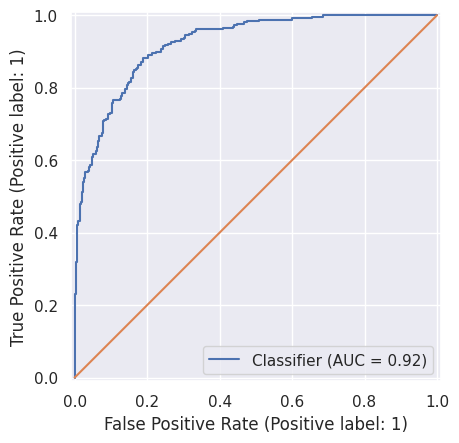

In [ ]:
metrics.RocCurveDisplay.from_predictions(test['is_attack'],test['openai_proba'])
plt.plot([0,1],[0,1])
plt.show()

## Fine-tuning Roberta

In [ ]:
torch.cuda.empty_cache()

In [ ]:
model_ckpt = "roberta-base"
model = AutoModelForSequenceClassification.from_pretrained(model_ckpt,num_labels=2).to("cuda")
tokenizer = AutoTokenizer.from_pretrained(model_ckpt)

In [ ]:
train, validation = train_test_split(train,test_size=0.2,random_state=42)
train = train.reset_index(drop=True)
validation = validation.reset_index(drop=True)

In [ ]:
train = train.rename(columns={'is_attack':'label'})
validation = validation.rename(columns={'is_attack':'label'})

In [ ]:
#training model
def tokenize_function(data):
    return tokenizer(data['preprocessed_url'], padding='max_length', truncation=True)

#given two dataframes train and validation
#the target column of train and validation must be named "label". It must be of type int

train_dataset = Dataset.from_pandas(train)
validation_dataset = Dataset.from_pandas(validation)

train_dataset = train_dataset.map(tokenize_function, batched=True)
validation_dataset = validation_dataset.map(tokenize_function, batched=True)

training_args = TrainingArguments(
    output_dir='./results',
    eval_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=64,
    num_train_epochs=3,
    weight_decay=0.01
)

trainer = Trainer(
    model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=validation_dataset
)

trainer.train()

In [ ]:
inputs = tokenizer(list(test['preprocessed_url']), padding=True, truncation=True, return_tensors='pt',max_length=512)

with torch.no_grad():
    logits = model(**inputs).logits

predictions = torch.argmax(logits, dim=1)

print(predictions)

In [ ]:
test['fine_tuned_pred'] = predictions.numpy()

In [ ]:
print(metrics.classification_report(test['is_attack'],test['fine_tuned_pred']))

## Retrain and save model

For experiments, the model is simply saved as a .pkl file to the bucket.

In [ ]:
def compute_embeddings(docs):
  embeddings = []
  for i in range(len(docs)//1000+1):
    response = client.embeddings.create(input=docs[1000*i:1000*(i+1)], model="text-embedding-3-small")
    embeddings += [np.array(x.embedding) for x in response.data]
  return embeddings

In [ ]:
X_train = np.array(compute_embeddings(list(df['preprocessed_url'])))

In [ ]:
Lr = LogisticRegression()

Lr.fit(X_train,df['is_attack'])

LogisticRegression()

In [ ]:
file_path = 'cyber/models/linear-classifier/cyber_classification_model.pkl'
blob = bucket.blob(file_path)

with blob.open("wb") as f:
    pickle.dump(Lr, f)